# LeetCode #476: Number Complement

https://leetcode.com/problems/number-complement/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (bit-by-bit flip)** | $O(\log n)$ | $O(1)$ |
| **Optimal: Bit Mask Flip ★** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (bit-by-bit flip)
Iterate over each bit position of num, flip it, and accumulate the result. Requires tracking the bit length explicitly with a counter.

### Optimal: Bit Mask Flip ★
Compute a mask of all-1s with the same bit length as `num` by left-shifting 1 until it exceeds `num`, then subtracting 1. XOR `num` with this mask flips only the significant bits.

**Why this is better than Brute Force:** Single XOR operation after mask construction — cleaner and equally efficient; no per-bit loop needed.

**Constraints:**
* $1 \le$ num $\le 2^{31} - 1$

## Solutions

### C#

In [ ]:
public int FindComplement(int num) {
    // Build a mask of all 1s with the same number of bits as num
    int mask = 1;
    while (mask <= num) mask <<= 1;
    // XOR flips all bits within the significant range
    return (mask - 1) ^ num;
}

### Python

In [ ]:
def findComplement(self, num: int) -> int:
    # Build a mask of all 1s with the same number of bits as num
    mask = 1
    while mask <= num:
        mask <<= 1
    # XOR flips all bits within the significant range
    return (mask - 1) ^ num

### Go

In [ ]:
func findComplement(num int) int {
    // Build a mask of all 1s with the same number of bits as num
    mask := 1
    for mask <= num {
        mask <<= 1
    }
    // XOR flips all bits within the significant range
    return (mask - 1) ^ num
}

### Rust

In [ ]:
pub fn find_complement(num: i32) -> i32 {
    // Build a mask of all 1s with the same number of bits as num
    let mut mask = 1i32;
    while mask <= num {
        mask <<= 1;
    }
    // XOR flips all bits within the significant range
    (mask - 1) ^ num
}

## Example Scenarios

**1. Common Case**
**Input:** num = 5 (binary: 101)
mask builds to 8 (1000). mask-1 = 7 (111). 111⊕101 = **010** = **2**. Every bit flipped within the 3-bit range.

**2. Slightly Complex**
**Input:** num = 7 (binary: 111)
mask builds to 8 (1000). mask-1 = 7 (111). 111⊕111 = **000** = **0**. Complement of all-ones is all-zeros.

**3. Edge Case: Time Factor**
**Input:** num = $2^{30}$ (a 31-bit number, just one bit set)
The `while (mask <= num)` loop runs 31 times. Mask reaches $2^{31}$. `(mask-1)` = $2^{31}-1$ (all 31 lower bits set). XOR with num gives $2^{31}-1 - 2^{30} = 2^{30}-1$. The loop length scales with $O(\log n)$.

**4. Edge Case: Space Factor**
**Input:** num = 1 (binary: 1)
mask starts at 1, immediately exceeds num at mask=2. mask-1=1. 1⊕1=**0**. Minimum case: single iteration, result is 0. $O(1)$ space.

**5. Almost-Impossible but Plausible**
**Input:** num = $2^{31} - 1$ (max positive 32-bit signed, binary: 31 ones)
mask must reach $2^{31}$ but as a signed int, $2^{31}$ overflows to $-2^{31}$ — the `while (mask <= num)` check may fail or loop forever in C# if `int` is used for mask. Must ensure mask uses a wider type or use unsigned arithmetic. Rust panics on debug overflow; C# wraps silently. Result: **0** (all bits flip).

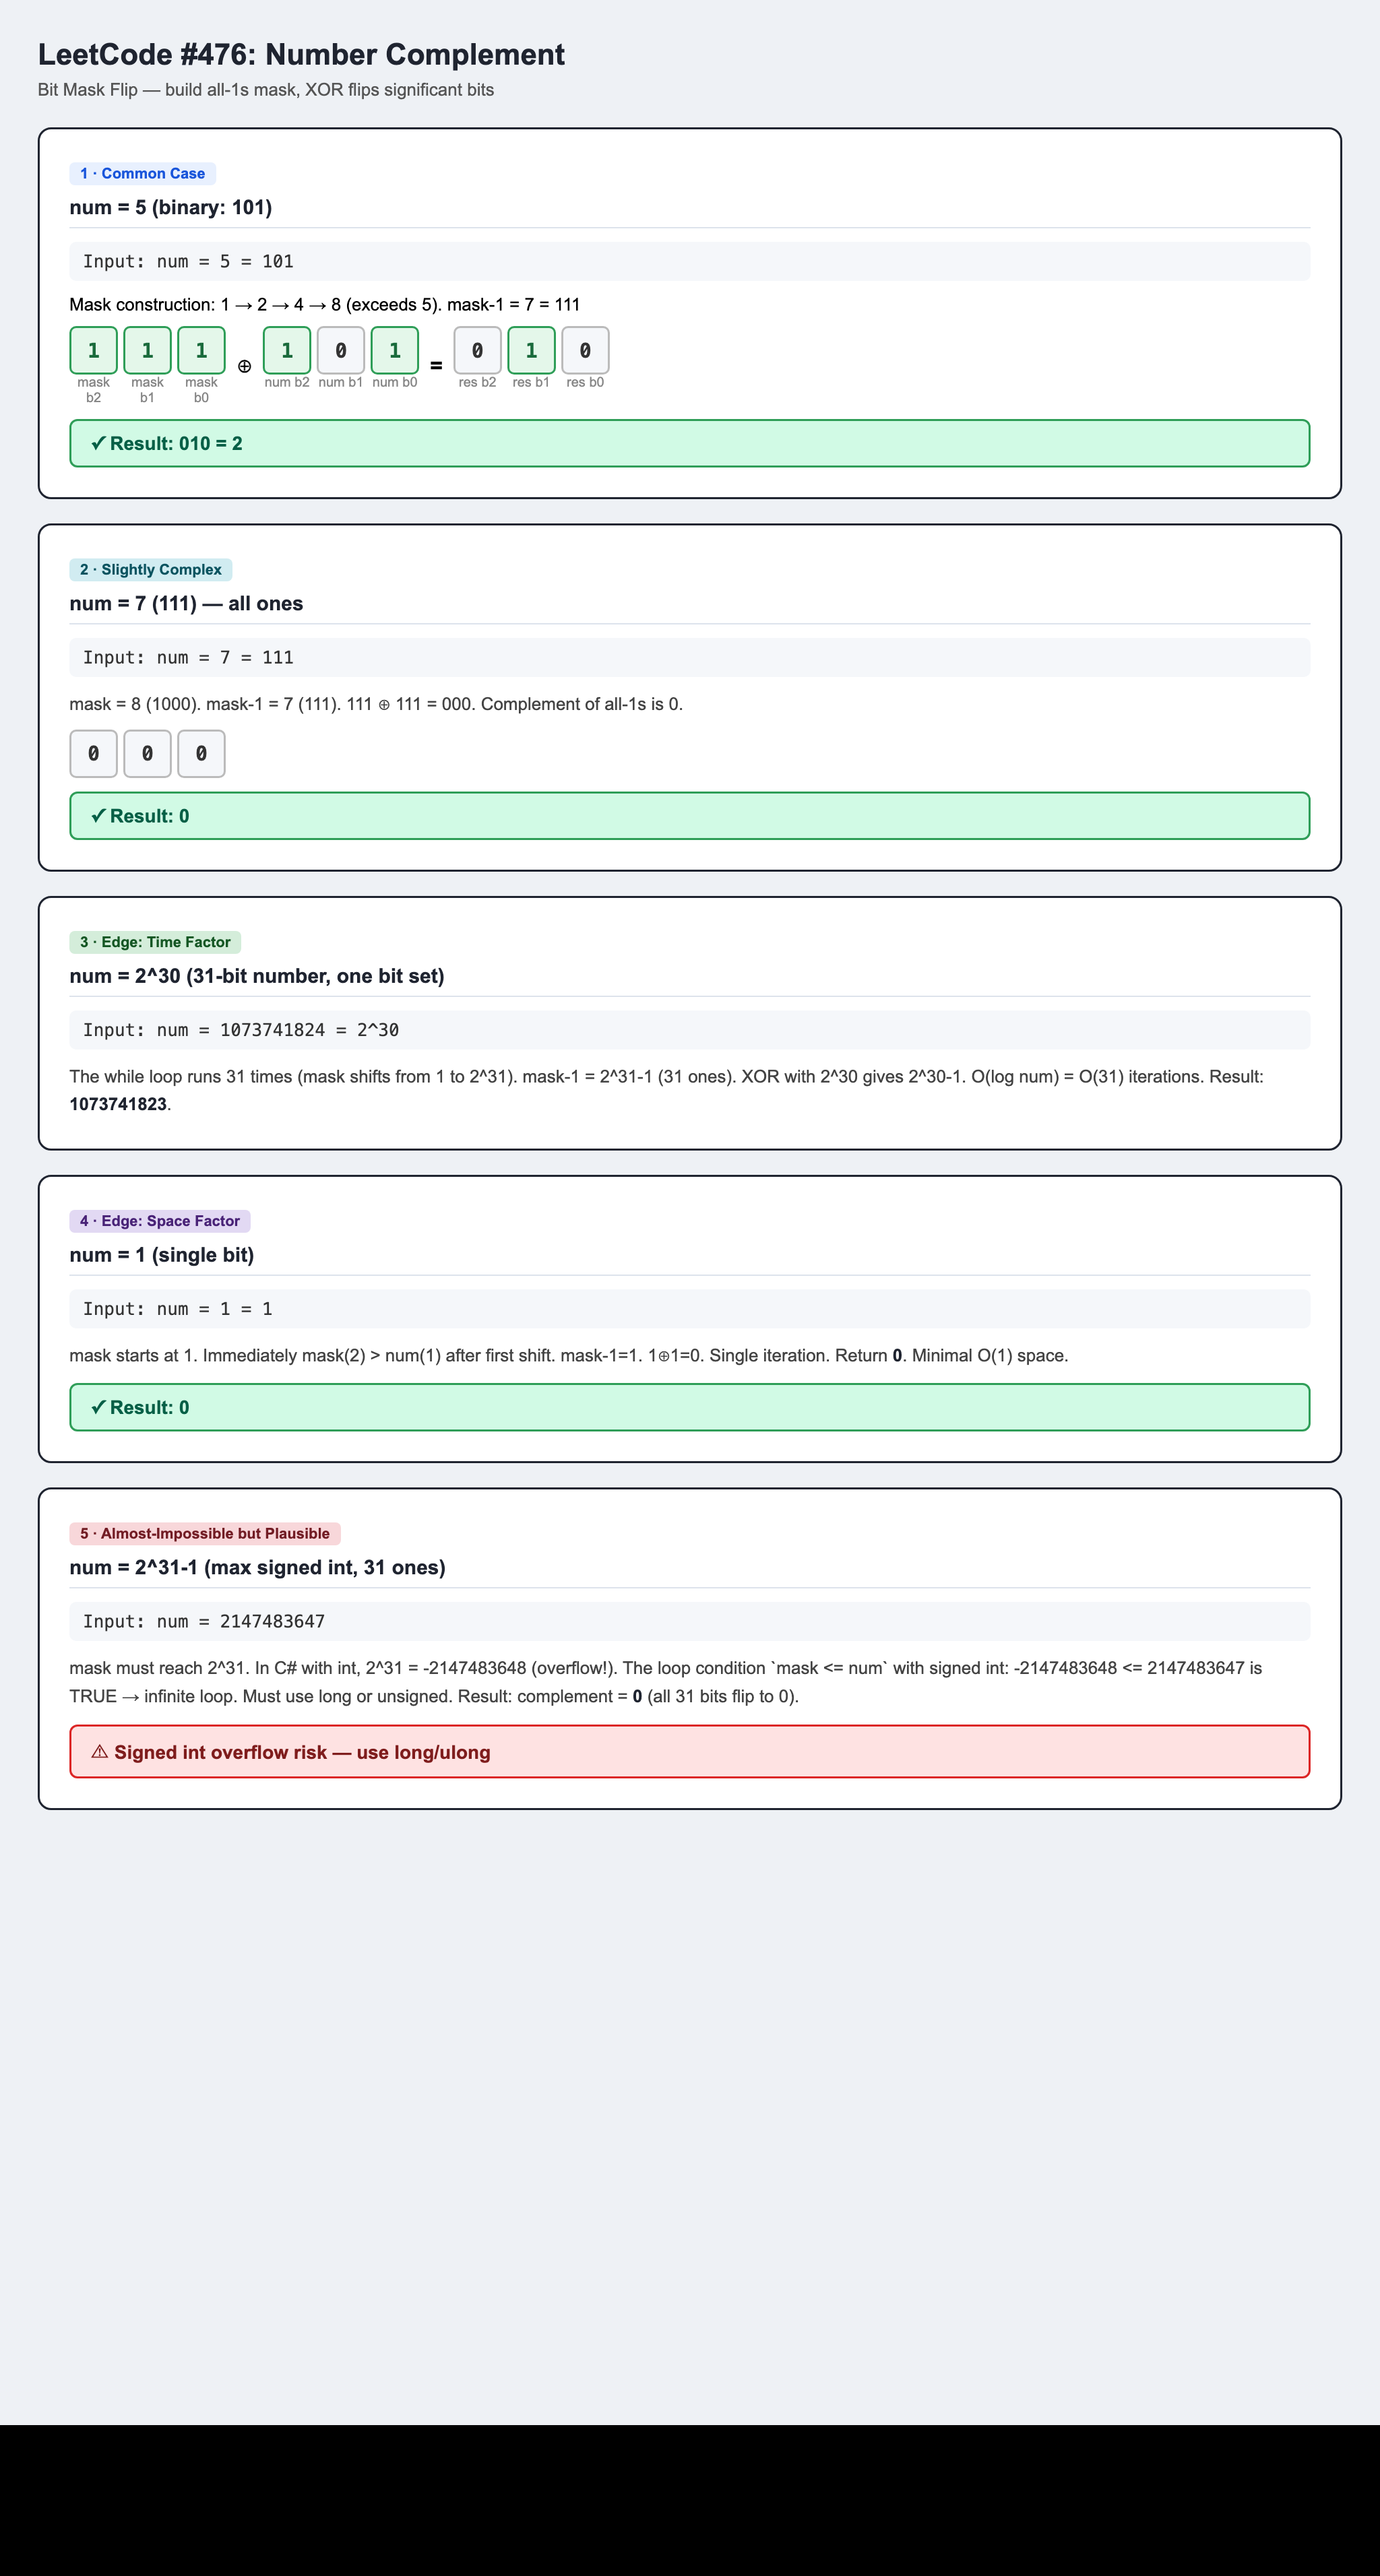